<a href="https://colab.research.google.com/github/Bobby-Bao/pic16b/blob/main/NMF_Test_Code_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Constrained NMF for Transition Matrix Learning

---

## 1. Problem Definition
The objective is to recover the ground-truth transition matrix $W^* \in \mathbb{R}^{50 \times 50}$ from the observed data $X \in \mathbb{R}^{50 \times 500}$. The data is generated based on the following factorization:
$$X = W H$$

## 2. Model Constraints
To ensure the matrix $W$ can be interpreted as a **Transition Matrix**, we enforce the following properties:

* **Non-negativity (NMF)**: $W_{ij} \ge 0, H_{ij} \ge 0$.
* **Row Stochasticity**: Each row of $W$ must sum to 1, representing a valid probability distribution:
$$\sum_{j=1}^{50} W_{ij} = 1, \quad \forall i \in \{1, \dots, 50\}$$
* **Sparsity Control**: $H$ is generated with high sparsity (controlled number of zeros) to facilitate the identifiability of $W$.

## 3. The Machine Learning Task
This is a constrained optimization problem where we minimize the reconstruction loss:

$$
\begin{aligned}
\min_{W, H} \quad & \mathcal{L} = \frac{1}{2} \|X - WH\|_F^2 + \lambda \|H\|_1 \\
\text{subject to} \quad & W \mathbf{1} = \mathbf{1} \\
& W, H \ge 0
\end{aligned}
$$

## 4. Operational Workflow
1.  **Step 0 (Synthesis)**: Generate $W$ (as a transition matrix) and sparse $H$, then compute $X = WH$.
2.  **Step 1 (Learning)**: From the observed $X$, use an ML optimizer to learn the estimate $\hat{W}$.
3.  **Step 2 (Application)**: Use the learned $\hat{W}$ to parameterize the **Optimal Control Problem**.

---

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from collections import defaultdict

In [ ]:
# 1. Device & Utils
# ==========================================
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def frob(A, B):
    return torch.norm(A - B, p="fro")

@torch.no_grad()
def row_sum_err(W):
    return torch.max(torch.abs(W.sum(dim=1) - 1.0)).item()

In [ ]:
# 2. Data Generation
# ==========================================
def generate_row_stochastic_W(n=50, seed=0, device="cpu"):
    """
    The rows of W sum to 1.
    It can be seen as a transition matrix.
    """
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    W = torch.rand((n, n), generator=g, device=device)
    W = W / W.sum(dim=1, keepdim=True)
    return W

def generate_sparse_H(n=50, m=500, sparsity=0.8, seed=1, device="cpu", col_normalize=False, eps=1e-12):
    """
    sparsity = fraction zeros (approximately). mask keeps entries with prob (1 - sparsity).
    col_normalize: if True, each column sums to 1 (helps identifiability with stochastic W).
    """
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    H_dense = torch.rand((n, m), generator=g, device=device)
    mask = (torch.rand((n, m), generator=g, device=device) > sparsity).float()
    H = H_dense * mask
    # the col_sum = 1 is not required in the setup, just for experiment
    if col_normalize:
        H = H / (H.sum(dim=0, keepdim=True) + eps)
    return H

In [ ]:
# 3. Math & Projections
# ==========================================
def project_rows_to_simplex(V, z=1.0, eps=1e-12):
    """
    Duchi et al. projection of each row onto simplex {w>=0, sum w = z}.
    V: (n, d)
    """
    U, _ = torch.sort(V, dim=1, descending=True)
    cssv = torch.cumsum(U, dim=1)
    ind = torch.arange(1, V.size(1) + 1, device=V.device).view(1, -1)

    cond = U - (cssv - z) / ind > 0
    rho = cond.sum(dim=1) - 1
    rho = torch.clamp(rho, min=0)

    theta = (cssv.gather(1, rho.view(-1, 1)) - z) / (rho.view(-1, 1) + 1)
    W = torch.clamp(V - theta, min=0.0)

    # numerical tidy: renormalize
    W = W / (W.sum(dim=1, keepdim=True) + eps)
    return W


In [ ]:
# 4. Models
# ==========================================
class NMFSoftmaxW(nn.Module):
    """
    W_hat: row-softmax => nonneg + row sum 1
    H_hat: softplus => nonneg, optional column normalization
    """
    def __init__(self, n=50, m=500, init_scale=1.0, device="cpu", H_col_normalize=False, eps=1e-12):
        super().__init__()
        self.n, self.m = n, m
        self.eps = eps
        self.H_col_normalize = H_col_normalize

        self.W_logits = nn.Parameter(init_scale * torch.randn(n, n, device=device))
        self.H_param  = nn.Parameter(init_scale * torch.randn(n, m, device=device))

    def W_hat(self):
        return F.softmax(self.W_logits, dim=1)

    def H_hat_full(self):
        H = F.softplus(self.H_param)
        if self.H_col_normalize:
            H = H / (H.sum(dim=0, keepdim=True) + self.eps)
        return H

    def forward_chunk(self, cols):
        W = self.W_hat()
        Hc = self.H_hat_full()[:, cols]
        return W @ Hc

class NMFProjectedW(nn.Module):
    """
    W_hat: parameter directly optimized, projected onto simplex after each step.
    H_hat: softplus => nonneg, optional column normalization
    """
    def __init__(self, n=50, m=500, init_scale=0.01, device="cpu", H_col_normalize=False, eps=1e-12):
        super().__init__()
        self.n, self.m = n, m
        self.eps = eps
        self.H_col_normalize = H_col_normalize

        self.W_param = nn.Parameter(init_scale * torch.randn(n, n, device=device))
        self.H_param = nn.Parameter(init_scale * torch.randn(n, m, device=device))

        with torch.no_grad():
            self.W_param.copy_(project_rows_to_simplex(self.W_param))

    def W_hat(self):
        return self.W_param

    def H_hat_full(self):
        H = F.softplus(self.H_param)
        if self.H_col_normalize:
            H = H / (H.sum(dim=0, keepdim=True) + self.eps)
        return H

    def forward_chunk(self, cols):
        W = self.W_hat()
        Hc = self.H_hat_full()[:, cols]
        return W @ Hc

def projection_hook(model: NMFProjectedW):
    with torch.no_grad():
        model.W_param.copy_(project_rows_to_simplex(model.W_param))

In [ ]:
# 5. Training Engine
# ==========================================
def make_optimizer(model, method, lr):
    # Projection + Adam can be jittery; SGD momentum tends to behave nicer with projections.
    if method == "projection":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    else:
        return torch.optim.AdamW(model.parameters(), lr=lr)

def train_chunked(
    X, model, method,
    batch_cols=128, epochs=2000, lr=1e-2, l1_lambda=1e-3,
    print_every=0, use_amp=None, early_stopping=True, patience=30,
    min_delta=1e-5, restore_best=True, post_step_hook=None
):
    device = X.device
    m = X.size(1)

    # AMP default: only enable if CUDA and the problem is "big enough" to matter
    if use_amp is None:
        use_amp = (device.type == "cuda" and (X.numel() >= 2_000_000))

    opt = make_optimizer(model, method=method, lr=lr)
    scaler = GradScaler(enabled=(use_amp and device.type == "cuda"))
    all_cols = torch.arange(m, device=device)

    best_metric = float("inf")
    best_state = None
    bad_epochs = 0
    stopped_ep = epochs

    for ep in range(1, epochs + 1):
        perm = all_cols[torch.randperm(m, device=device)]

        total_loss, total_recon, total_l1 = 0.0, 0.0, 0.0
        total_items_recon = 0
        total_items_l1 = 0

        for start in range(0, m, batch_cols):
            cols = perm[start:start + batch_cols]
            Xc = X[:, cols]

            opt.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=(use_amp and device.type == "cuda")):
                X_hat_c = model.forward_chunk(cols)

                # ---- normalized losses (mean) ----
                recon = torch.mean((Xc - X_hat_c) ** 2)  # MSE over entries in chunk
                Hc = model.H_hat_full()[:, cols]
                l1 = torch.mean(torch.abs(Hc))           # mean L1 over entries in Hc
                loss = recon + l1_lambda * l1

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            if post_step_hook is not None:
                post_step_hook(model)

            # Accumulate as sums of means (weighted by counts) to make epoch avg consistent
            total_loss += loss.item() * Xc.numel()
            total_recon += recon.item() * Xc.numel()
            total_l1 += l1.item() * Hc.numel()
            total_items_recon += Xc.numel()
            total_items_l1 += Hc.numel()

        avg_recon = total_recon / max(total_items_recon, 1)
        avg_l1 = total_l1 / max(total_items_l1, 1)
        avg_loss = avg_recon + l1_lambda * avg_l1

        if (ep == 1) or (print_every > 0 and ep % print_every == 0):
            with torch.no_grad():
                W = model.W_hat()
                row_err = row_sum_err(W)
                minW = W.min().item()
                minH = model.H_hat_full().min().item()
                print(f"[ep {ep:4d}] avg_loss={avg_loss:.3e} avg_recon={avg_recon:.3e} avg_l1={avg_l1:.3e} "
                      f"| row_err={row_err:.2e} minW={minW:.2e} minH={minH:.2e}")

        if early_stopping:
            if avg_loss < best_metric - min_delta:
                best_metric = avg_loss
                bad_epochs = 0
                if restore_best:
                    with torch.no_grad():
                        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    stopped_ep = ep
                    if restore_best and best_state is not None:
                        model.load_state_dict(best_state)
                    break

    return model, stopped_ep, best_metric


In [ ]:
# 6. Evaluation & Trial Runners
# ==========================================

import numpy as np
import torch

def rel_frob(A, B, eps=1e-12):
    """Relative Frobenius error ||A-B||_F / ||B||_F."""
    return (torch.norm(A - B, p="fro") / (torch.norm(B, p="fro") + eps)).item()

@torch.no_grad()
def best_perm_relerr_greedy(W_hat, W_true, eps=1e-12):
    """
    Fast diagnostic permutation alignment (greedy) using row cosine similarity.
    This is NOT guaranteed optimal, but good for Step-1: check if permutation ambiguity
    is the main reason your W error looks large.
    """
    n = W_true.size(0)

    # Row-normalize for cosine similarity
    Wh = W_hat / (W_hat.norm(dim=1, keepdim=True) + eps)
    Wt = W_true / (W_true.norm(dim=1, keepdim=True) + eps)

    sim = Wh @ Wt.T  # (n, n)
    perm = [-1] * n
    used = set()

    for i in range(n):
        # sort candidate matches by similarity
        _, idxs = torch.sort(sim[i], descending=True)
        for j in idxs.tolist():
            if j not in used:
                perm[i] = j
                used.add(j)
                break

    perm = torch.tensor(perm, device=W_hat.device, dtype=torch.long)

    # Align W_true by the same permutation on rows & cols: P^T W P
    W_true_perm = W_true[perm][:, perm]
    return rel_frob(W_hat, W_true_perm)

@torch.no_grad()
def evaluate_model(model, W_true, X, markov_T=8, markov_trials=8):
    W_hat = model.W_hat()
    H_hat = model.H_hat_full()

    # --- metrics: absolute + relative + perm-aligned relative ---
    wdist = torch.norm(W_hat - W_true, p="fro").item()           # your old metric
    relerr = rel_frob(W_hat, W_true)                             # percent-like target metric
    relerr_perm = best_perm_relerr_greedy(W_hat, W_true)         # diagnostic

    recon = torch.norm(X - W_hat @ H_hat, p="fro").item()

    # Markov behavior gap: compare p0 W^t vs p0 W_hat^t over random initial distributions
    device = W_true.device
    n = W_true.size(0)

    gaps = []
    for _ in range(markov_trials):
        p0 = torch.rand((1, n), device=device)
        p0 = p0 / p0.sum(dim=1, keepdim=True)

        p_true = p0
        p_hat = p0
        for _t in range(markov_T):
            p_true = p_true @ W_true
            p_hat = p_hat @ W_hat
            gaps.append(torch.norm(p_true - p_hat, p=1).item())

    markov_gap = float(np.mean(gaps)) if gaps else 0.0

    # return more info (keeps backward compatibility if you want)
    return {
        "Wdist": float(wdist),
        "RelErr": float(relerr),
        "RelErr_perm": float(relerr_perm),
        "ReconF": float(recon),
        "MarkovGap": float(markov_gap),
    }

def run_trial(
    method, sparsity, seedW, seedH,
    n=50, m=500, epochs=2000, lr=1e-2, l1_lambda=1e-3,
    batch_cols=128, early_stopping=True, patience=30, min_delta=1e-5,
    use_amp=None, print_every=0,
    H_col_normalize=False,
):
    device = get_device()
    W_true = generate_row_stochastic_W(n=n, seed=seedW, device=device)
    H_true = generate_sparse_H(
        n=n, m=m, sparsity=sparsity, seed=seedH, device=device,
        col_normalize=H_col_normalize
    )
    X = W_true @ H_true

    if method == "softmax":
        model = NMFSoftmaxW(n=n, m=m, device=device, H_col_normalize=H_col_normalize)
        hook = None
    elif method == "projection":
        model = NMFProjectedW(n=n, m=m, device=device, H_col_normalize=H_col_normalize)
        hook = projection_hook
    else:
        raise ValueError("method must be 'softmax' or 'projection'")

    model, stop_ep, best_metric = train_chunked(
        X, model, method=method,
        batch_cols=batch_cols, epochs=epochs, lr=lr, l1_lambda=l1_lambda,
        print_every=print_every, use_amp=use_amp,
        early_stopping=early_stopping, patience=patience, min_delta=min_delta,
        restore_best=True, post_step_hook=hook
    )

    metrics = evaluate_model(model, W_true, X)

    return {
        "method": method,
        "sparsity": float(sparsity),
        "H_col_normalize": bool(H_col_normalize),
        "seedW": int(seedW),
        "seedH": int(seedH),
        **metrics,   # adds Wdist, RelErr, RelErr_perm, ReconF, MarkovGap
        "stop_ep": int(stop_ep),
        "best_metric": float(best_metric),
    }


# Experiment


In [ ]:
# 7. Experiment Definitions
# ==========================================
def experiment_sparsity_sweep(
    method="softmax",
    sparsities=(0.5, 0.7, 0.8, 0.9),
    trials=10, seedW0=0, seedH0=100,
    H_col_normalize=False,
    **train_kwargs
):
    results = []
    for sp in sparsities:
        for k in range(trials):
            res = run_trial(
                method=method, sparsity=sp,
                seedW=seedW0 + k, seedH=seedH0 + k,
                H_col_normalize=H_col_normalize,
                **train_kwargs
            )
            results.append(res)
    return results

def experiment_method_compare(
    sparsity=0.8,
    trials=10, seedW0=0, seedH0=100,
    H_col_normalize=False,
    **train_kwargs
):
    results = []
    for method in ["softmax", "projection"]:
        for k in range(trials):
            res = run_trial(
                method=method, sparsity=sparsity,
                seedW=seedW0 + k, seedH=seedH0 + k,
                H_col_normalize=H_col_normalize,
                **train_kwargs
            )
            results.append(res)
    return results


In [ ]:
# 8. Plotting & Summary Utilities
# ==========================================
def summarize(results, group_keys):
    groups = defaultdict(list)
    for r in results:
        key = tuple(r[k] for k in group_keys)
        groups[key].append(r)

    summary = []
    for key, rows in sorted(groups.items(), key=lambda kv: kv[0]):
        # old metrics
        w = np.array([x["Wdist"] for x in rows], dtype=float)
        re = np.array([x["ReconF"] for x in rows], dtype=float)
        mg = np.array([x["MarkovGap"] for x in rows], dtype=float)

        # new metrics
        rel = np.array([x["RelErr"] for x in rows], dtype=float)
        relp = np.array([x["RelErr_perm"] for x in rows], dtype=float)

        ep = np.array([x["stop_ep"] for x in rows], dtype=float)

        summary.append({
            **{k: v for k, v in zip(group_keys, key)},
            "Wdist_mean": float(w.mean()),
            "Wdist_std": float(w.std(ddof=1) if len(w) > 1 else 0.0),

            "RelErr_mean": float(rel.mean()),
            "RelErr_std": float(rel.std(ddof=1) if len(rel) > 1 else 0.0),

            "RelErr_perm_mean": float(relp.mean()),
            "RelErr_perm_std": float(relp.std(ddof=1) if len(relp) > 1 else 0.0),

            "Recon_mean": float(re.mean()),
            "Recon_std": float(re.std(ddof=1) if len(re) > 1 else 0.0),

            "MarkovGap_mean": float(mg.mean()),
            "MarkovGap_std": float(mg.std(ddof=1) if len(mg) > 1 else 0.0),

            "StopEp_mean": float(ep.mean()),
            "StopEp_std": float(ep.std(ddof=1) if len(ep) > 1 else 0.0),
            "N": int(len(rows))
        })
    return summary


def plot_sparsity_curve(summary, title):
    spars = [s["sparsity"] for s in summary]

    def errplot(ykey_mean, ykey_std, ylabel, ttl):
        ymean = [s[ykey_mean] for s in summary]
        ystd  = [s[ykey_std]  for s in summary]
        plt.figure()
        plt.errorbar(spars, ymean, yerr=ystd, marker='o', capsize=3)
        plt.xlabel("H sparsity (fraction zeros)")
        plt.ylabel(ylabel)
        plt.title(ttl)
        plt.show()

    errplot("Wdist_mean", "Wdist_std", "||W_hat - W||_F", title + " (W recovery)")
    errplot("Recon_mean", "Recon_std", "||X - W_hat H_hat||_F", title + " (reconstruction)")
    errplot("MarkovGap_mean", "MarkovGap_std", "Mean L1 gap of p0 W^t", title + " (Markov behavior)")
    # The goal is to make the error < 5%
    errplot("RelErr_mean", "RelErr_std", "RelErr = ||Ŵ-W||_F / ||W||_F", title + " (relative W error)")
    errplot("RelErr_perm_mean", "RelErr_perm_std", "Perm-Aligned RelErr", title + " (perm-aligned relative W error)")



def plot_method_bars(summary, title):
    methods = [s["method"] for s in summary]
    x = np.arange(len(methods))

    def bar(ykey_mean, ykey_std, ylabel, ttl):
        ymean = [s[ykey_mean] for s in summary]
        ystd  = [s[ykey_std]  for s in summary]
        plt.figure()
        plt.bar(x, ymean, yerr=ystd, capsize=4)
        plt.xticks(x, methods)
        plt.ylabel(ylabel)
        plt.title(ttl)
        plt.show()

    bar("Wdist_mean", "Wdist_std", "||W_hat - W||_F", title + " (W recovery)")
    bar("Recon_mean", "Recon_std", "||X - W_hat H_hat||_F", title + " (reconstruction)")
    bar("MarkovGap_mean", "MarkovGap_std", "Mean L1 gap of p0 W^t", title + " (Markov behavior)")

# Test 1

Using device: cuda
[ep    1] avg_loss=3.279e-01 avg_recon=3.271e-01 avg_l1=8.062e-01 | row_err=1.19e-07 minW=4.13e-04 minH=1.54e-02
[ep    1] avg_loss=3.209e-01 avg_recon=3.201e-01 avg_l1=8.039e-01 | row_err=1.19e-07 minW=4.24e-04 minH=2.16e-02
[ep    1] avg_loss=3.301e-01 avg_recon=3.293e-01 avg_l1=8.094e-01 | row_err=2.38e-07 minW=3.68e-04 minH=1.59e-02
[ep    1] avg_loss=3.267e-01 avg_recon=3.259e-01 avg_l1=8.082e-01 | row_err=1.19e-07 minW=5.02e-04 minH=1.94e-02
[ep    1] avg_loss=3.255e-01 avg_recon=3.247e-01 avg_l1=8.096e-01 | row_err=1.19e-07 minW=3.75e-04 minH=2.50e-02
[ep    1] avg_loss=3.233e-01 avg_recon=3.225e-01 avg_l1=8.068e-01 | row_err=1.19e-07 minW=5.38e-04 minH=1.33e-02
[ep    1] avg_loss=3.266e-01 avg_recon=3.258e-01 avg_l1=8.042e-01 | row_err=1.19e-07 minW=2.51e-04 minH=1.74e-02
[ep    1] avg_loss=3.248e-01 avg_recon=3.240e-01 avg_l1=8.076e-01 | row_err=1.19e-07 minW=2.42e-04 minH=2.24e-02
[ep    1] avg_loss=3.308e-01 avg_recon=3.300e-01 avg_l1=8.080e-01 | row_err=1

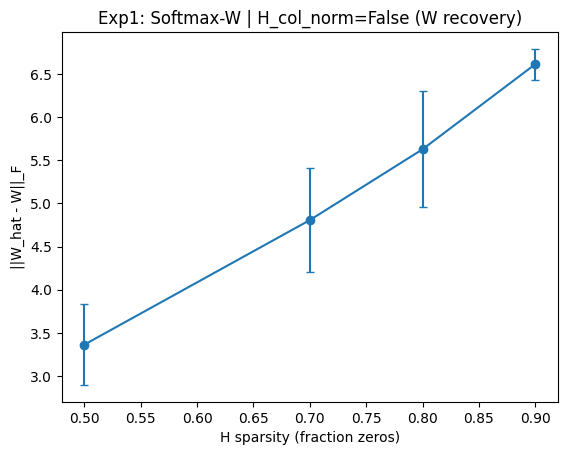

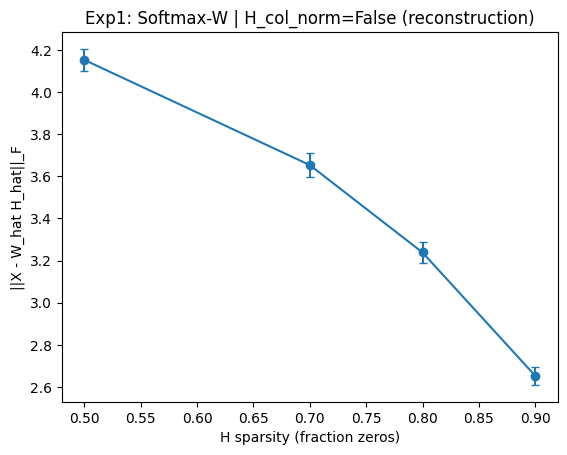

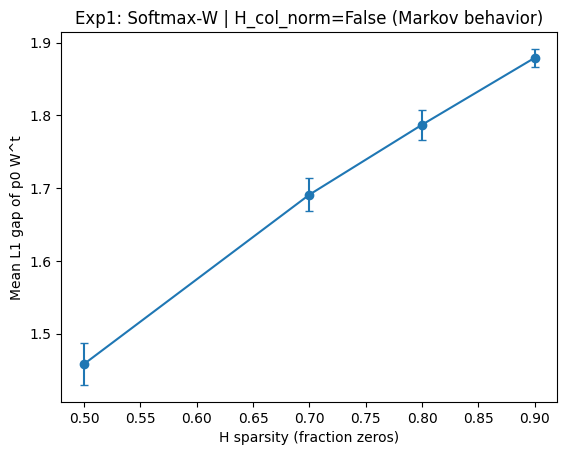

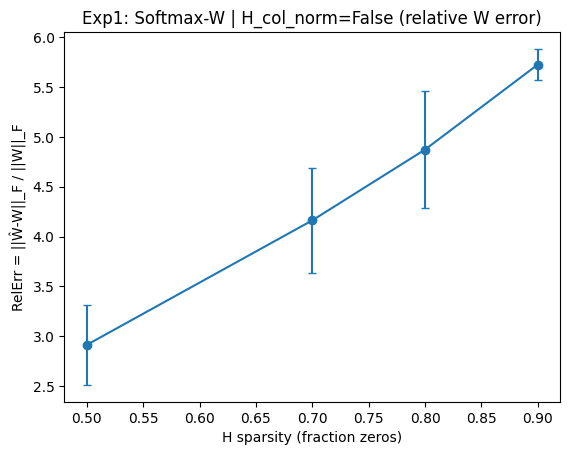

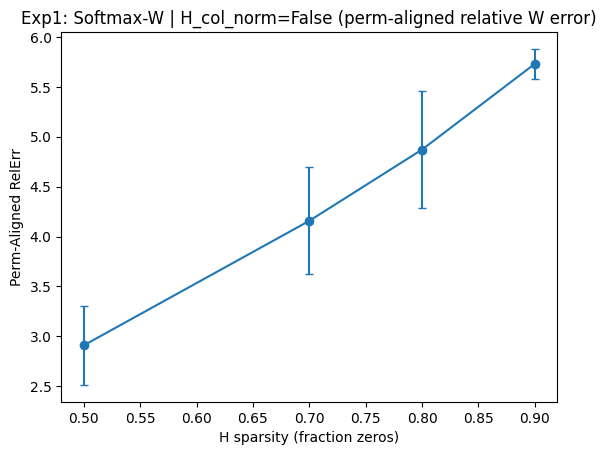

[ep    1] avg_loss=2.935e-05 avg_recon=9.348e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=2.32e-04 minH=2.07e-04
[ep    1] avg_loss=2.990e-05 avg_recon=9.902e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.86e-04 minH=5.39e-04
[ep    1] avg_loss=2.913e-05 avg_recon=9.131e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.61e-04 minH=3.35e-04
[ep    1] avg_loss=2.883e-05 avg_recon=8.834e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.30e-04 minH=3.34e-04
[ep    1] avg_loss=3.000e-05 avg_recon=9.996e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=1.83e-04 minH=5.02e-04
[ep    1] avg_loss=2.863e-05 avg_recon=8.626e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=5.25e-04 minH=5.26e-04
[ep    1] avg_loss=2.877e-05 avg_recon=8.774e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=1.68e-04 minH=6.38e-04
[ep    1] avg_loss=2.919e-05 avg_recon=9.190e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.79e-04 minH=4.48e-04
[ep    1] avg_loss=2.924e-05 avg_recon=9.236e-06 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.90e-

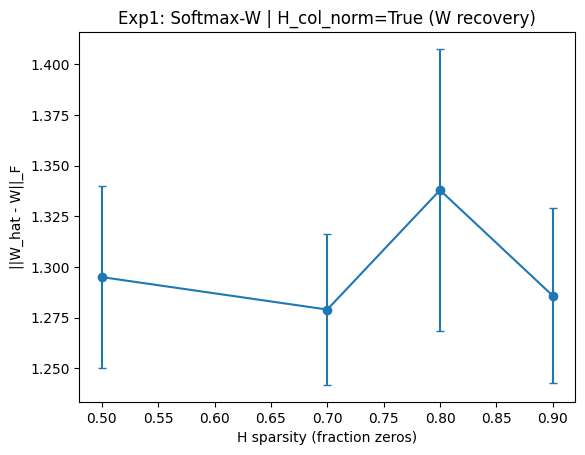

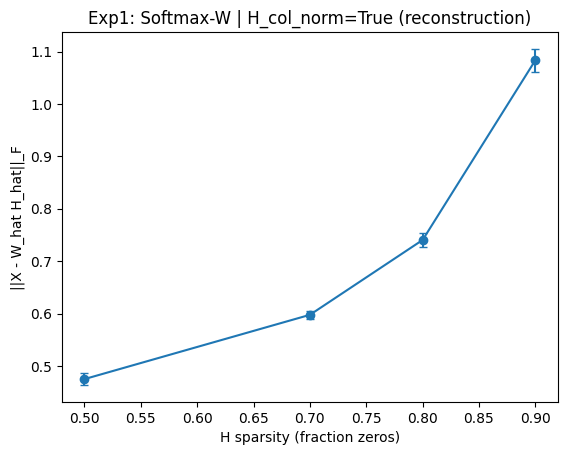

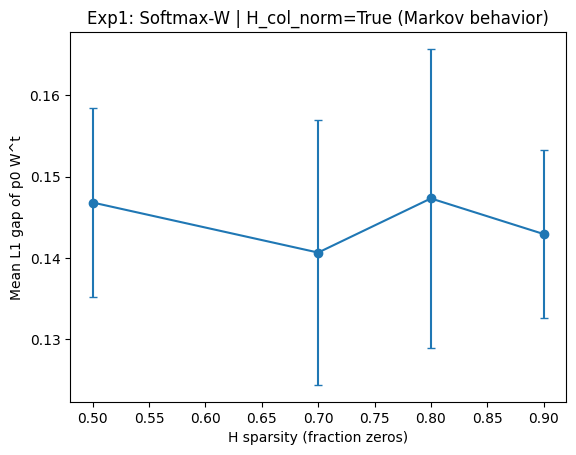

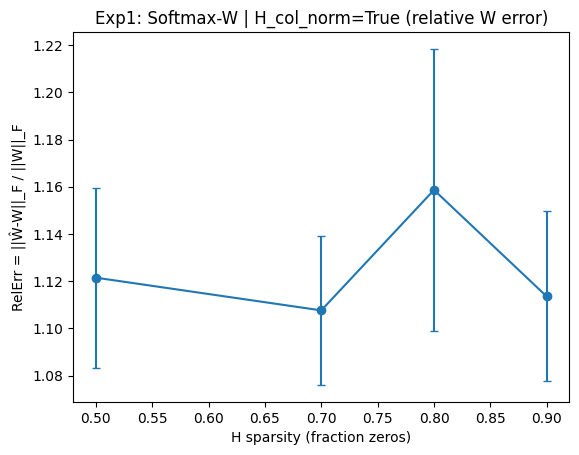

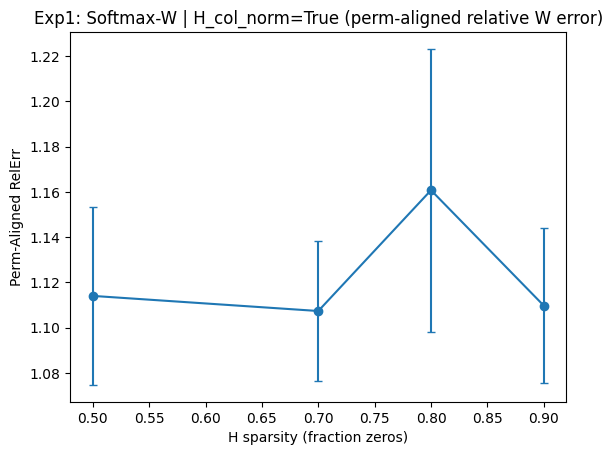

[ep    1] avg_loss=5.183e-01 avg_recon=5.175e-01 avg_l1=8.096e-01 | row_err=1.19e-07 minW=5.28e-04 minH=1.33e-02
[ep    1] avg_loss=5.228e-01 avg_recon=5.220e-01 avg_l1=8.130e-01 | row_err=1.19e-07 minW=4.41e-04 minH=1.73e-02
[ep    1] avg_loss=5.097e-01 avg_recon=5.089e-01 avg_l1=8.030e-01 | row_err=1.19e-07 minW=3.44e-04 minH=1.93e-02
[ep    1] avg_loss=5.140e-01 avg_recon=5.132e-01 avg_l1=8.061e-01 | row_err=1.19e-07 minW=2.51e-04 minH=1.92e-02
[ep    1] avg_loss=5.088e-01 avg_recon=5.080e-01 avg_l1=8.053e-01 | row_err=1.19e-07 minW=4.84e-04 minH=1.56e-02
[ep    1] avg_loss=5.157e-01 avg_recon=5.149e-01 avg_l1=8.077e-01 | row_err=1.19e-07 minW=3.29e-04 minH=2.11e-02
[ep    1] avg_loss=5.100e-01 avg_recon=5.091e-01 avg_l1=8.035e-01 | row_err=1.19e-07 minW=1.61e-04 minH=2.06e-02
[ep    1] avg_loss=5.056e-01 avg_recon=5.048e-01 avg_l1=8.022e-01 | row_err=1.19e-07 minW=3.36e-04 minH=1.91e-02
[ep    1] avg_loss=5.154e-01 avg_recon=5.146e-01 avg_l1=8.058e-01 | row_err=1.19e-07 minW=2.27e-

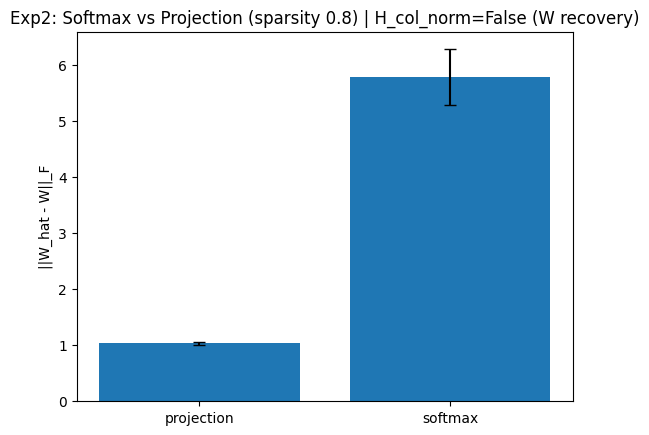

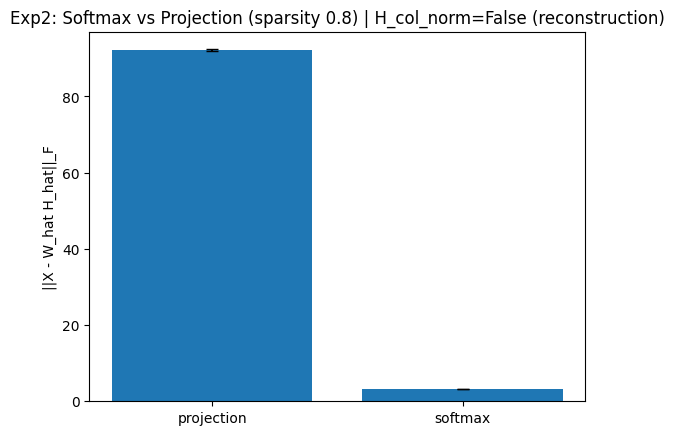

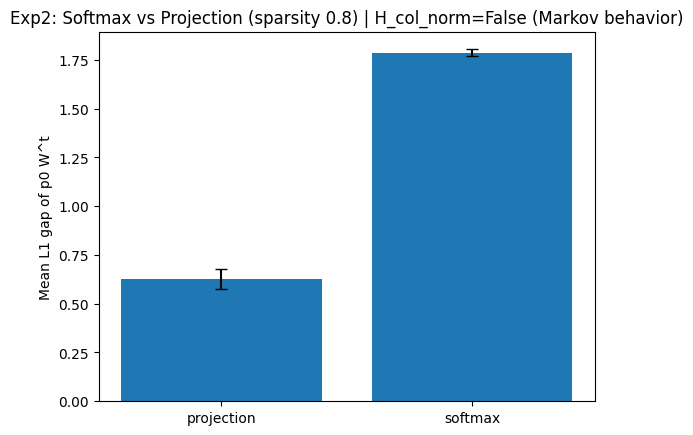

[ep    1] avg_loss=4.219e-05 avg_recon=2.219e-05 avg_l1=2.000e-02 | row_err=2.38e-07 minW=3.96e-04 minH=3.90e-04
[ep    1] avg_loss=4.253e-05 avg_recon=2.253e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=2.92e-04 minH=6.02e-04
[ep    1] avg_loss=4.109e-05 avg_recon=2.109e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.14e-04 minH=6.91e-04
[ep    1] avg_loss=4.186e-05 avg_recon=2.186e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=2.44e-04 minH=3.37e-04
[ep    1] avg_loss=4.115e-05 avg_recon=2.115e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.31e-04 minH=5.69e-04
[ep    1] avg_loss=4.258e-05 avg_recon=2.258e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=4.02e-04 minH=2.11e-04
[ep    1] avg_loss=4.046e-05 avg_recon=2.046e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.41e-04 minH=3.73e-04
[ep    1] avg_loss=4.160e-05 avg_recon=2.160e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=3.35e-04 minH=3.94e-04
[ep    1] avg_loss=4.168e-05 avg_recon=2.168e-05 avg_l1=2.000e-02 | row_err=1.19e-07 minW=4.68e-

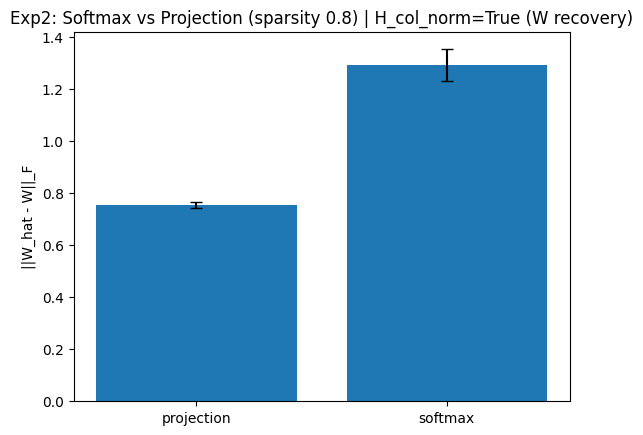

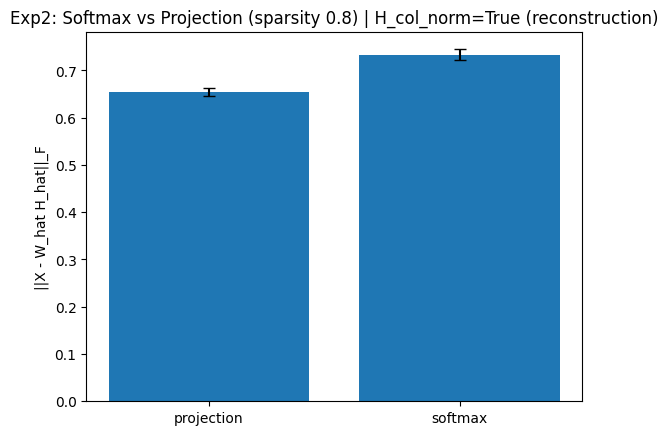

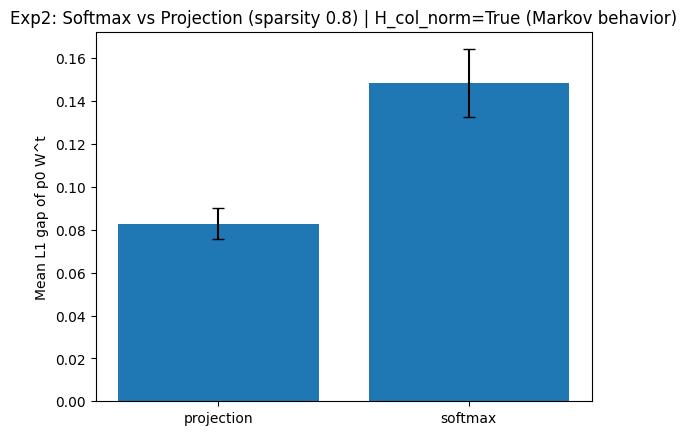

In [ ]:
# 9. Execution Block
# ==========================================
if __name__ == "__main__":
    device = get_device()
    print("Using device:", device)

    common_train_kwargs = dict(
        n=50, m=500,
        epochs=2000,
        lr=1e-2,
        l1_lambda=1e-3,
        batch_cols=128,
        early_stopping=True,
        patience=30,
        min_delta=1e-5,
        use_amp=None,      # let script decide
        print_every=0
    )

    # ---- Exp1: Sparsity sweep (softmax) without/with H column normalization ----
    for H_col_norm in [False, True]:
        res1 = experiment_sparsity_sweep(
            method="softmax",
            sparsities=(0.5, 0.7, 0.8, 0.9),
            trials=10,
            seedW0=0, seedH0=100,
            H_col_normalize=H_col_norm,
            **common_train_kwargs
        )
        sum1 = summarize(res1, group_keys=("sparsity",))
        print(f"\n[Exp1] Sparsity sweep (softmax) | H_col_normalize={H_col_norm}")
        for s in sum1:
            print(s)
        plot_sparsity_curve(sum1, title=f"Exp1: Softmax-W | H_col_norm={H_col_norm}")

    # ---- Exp2: Method compare at sparsity=0.8, without/with H column normalization ----
    for H_col_norm in [False, True]:
        res2 = experiment_method_compare(
            sparsity=0.8,
            trials=10,
            seedW0=0, seedH0=100,
            H_col_normalize=H_col_norm,
            **common_train_kwargs
        )
        sum2 = summarize(res2, group_keys=("method",))
        print(f"\n[Exp2] Method compare @ sparsity=0.8 | H_col_normalize={H_col_norm}")
        for s in sum2:
            print(s)
        plot_method_bars(sum2, title=f"Exp2: Softmax vs Projection (sparsity 0.8) | H_col_norm={H_col_norm}")

### Experimental Summary

In one sentence, the model is barely learning anything. In our initial evaluations, we observed an error rate of approximately 10%. However, it is crucial to clarify that this metric represents the **relative reconstruction error** ($\frac{\|X - \hat{W}\hat{H}\|_F}{\|X\|_F}$), rather than the recovery error of the transition matrix $W$ ($\frac{\|\hat{W} - W\|_F}{\|W\|_F}$).

Specifically, the early trials demonstrated the following:
* **Without $H$ column normalization (Try 1):** The relative reconstruction error was approximately 14.5% ($1.44 \times 10^{-1}$)[cite: 233, 234]. Meanwhile, the relative $W$ error remained extremely high at 4.24[cite: 231, 232].
* **With $H$ column normalization (Try 2):** The relative reconstruction error dropped to approximately 9.6% ($9.60 \times 10^{-2}$)[cite: 308, 311]. Despite this tight reconstruction of the observed data, the relative $W$ error was still substantial at 1.35[cite: 307, 310].

Therefore, achieving a $\approx$ 10% relative reconstruction error strictly reflects the model's capacity to fit the observed data matrix $X$. It does not indicate successful recovery of the ground-truth transition matrix $W$. This discrepancy further underscores the core finding: minimizing reconstruction loss under standard NMF is insufficient for identifying the true underlying transition dynamics without proper structural constraints.

We conduct controlled synthetic experiments to evaluate the recovery of a ground-truth transition matrix $W \in \mathbb{R}^{50 \times 50}$ from observations $X = WH$, where $W$ is row-stochastic and nonnegative, and $H$ is sparse and nonnegative. The learning task is formulated as a constrained NMF problem with row-stochasticity enforced either via softmax parameterization or projection onto the probability simplex.

#### 1. Effect of Sparsity

We vary the sparsity level of $H$ (fraction of zeros from $0.5$ to $0.9$). When no column normalization is imposed on $H$, reconstruction error decreases as sparsity increases, but the recovery error $\|\hat{W} - W\|_F$ increases significantly. This demonstrates that good reconstruction does not imply correct operator recovery, highlighting the non-identifiability of $W$ under scaling ambiguities in standard NMF.

When column normalization is applied to $H$, recovery of $W$ becomes stable across sparsity levels. The Frobenius error remains low and nearly constant, and the induced multi-step Markov behavior of $\hat{W}$ closely matches that of the true $W$. This indicates that structural constraints on $H$ are essential for identifiability of the transition matrix.

#### 2. Method Comparison

We compare two parameterizations:
* Softmax-based row-stochastic parameterization
* Projection-based simplex constraint

Without column normalization, both methods fail to recover the true transition matrix. With normalization, both improve significantly, but the softmax parameterization consistently achieves lower recovery error and smaller Markov behavior gap, indicating better stability and optimization behavior.

#### 3. Key Findings

* Reconstruction accuracy alone is not a reliable indicator of transition matrix recovery.
* Identifiability of $W$ critically depends on structural constraints on $H$.
* Softmax parameterization provides a more stable and accurate learning framework for row-stochastic operators.

# Other ML Methods

### Alternating Algorithm(Still unsupervised)

In [ ]:
@torch.no_grad()
def initialize_model_svd(model, X):
    device = X.device

    # SVD
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)


    U_k = U[:, :model.n]
    S_k = S[:model.n]
    Vh_k = Vh[:model.n, :]

    W_init = torch.abs(U_k @ torch.diag(torch.sqrt(S_k)))
    H_init = torch.abs(torch.diag(torch.sqrt(S_k)) @ Vh_k)


    W_init = W_init / (W_init.sum(dim=1, keepdim=True) + 1e-12)


    if hasattr(model, 'W_logits'):
        # softmax
        model.W_logits.copy_(torch.log(W_init + 1e-12))
    elif hasattr(model, 'W_param'):
        model.W_param.copy_(W_init)

    # softplus(x)
    model.H_param.copy_(H_init)

In [ ]:
def train_alternating_chunked(
    X, model,
    batch_cols=128, epochs=2000, lr=1e-2, l1_lambda=1e-3,
    print_every=0, use_amp=None, early_stopping=True, patience=30,
    min_delta=1e-5, restore_best=True, post_step_hook=None
):
    device = X.device
    m = X.size(1)


    if use_amp is None:
        use_amp = (device.type == "cuda" and (X.numel() >= 2_000_000))

    if hasattr(model, 'W_logits'):
        opt_W = torch.optim.AdamW([model.W_logits], lr=lr)
    else:
        opt_W = torch.optim.AdamW([model.W_param], lr=lr)

    opt_H = torch.optim.AdamW([model.H_param], lr=lr)

    scaler = GradScaler(enabled=(use_amp and device.type == "cuda"))
    all_cols = torch.arange(m, device=device)

    best_metric = float("inf")
    best_state = None
    bad_epochs = 0
    stopped_ep = epochs

    for ep in range(1, epochs + 1):
        perm = all_cols[torch.randperm(m, device=device)]
        total_loss, total_recon, total_l1 = 0.0, 0.0, 0.0
        total_items = 0

        current_l1_lambda = l1_lambda * min(1.0, ep / (epochs * 0.2))

        for start in range(0, m, batch_cols):
            cols = perm[start:start + batch_cols]
            Xc = X[:, cols]

            # ==============================
            # Alternate
            # ==============================
            opt_H.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", enabled=(use_amp and device.type == "cuda")):
                X_hat_c = model.forward_chunk(cols)
                recon = torch.mean((Xc - X_hat_c) ** 2)
                Hc = model.H_hat_full()[:, cols]
                l1 = torch.mean(torch.abs(Hc))
                loss_H = recon + current_l1_lambda * l1

            scaler.scale(loss_H).backward()
            scaler.step(opt_H)

            # ==============================
            # Alternate
            # ==============================
            opt_W.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", enabled=(use_amp and device.type == "cuda")):
                X_hat_c = model.forward_chunk(cols)
                recon = torch.mean((Xc - X_hat_c) ** 2)
                Hc = model.H_hat_full()[:, cols]
                l1 = torch.mean(torch.abs(Hc))
                loss_W = recon + current_l1_lambda * l1

            scaler.scale(loss_W).backward()
            scaler.step(opt_W)

            scaler.update()

            if post_step_hook is not None:
                post_step_hook(model)

            total_loss += loss_W.item() * Xc.numel()
            total_recon += recon.item() * Xc.numel()
            total_l1 += l1.item() * Hc.numel()
            total_items += Xc.numel()

        avg_recon = total_recon / max(total_items, 1)
        avg_l1 = total_l1 / max(total_items, 1)
        avg_loss = avg_recon + current_l1_lambda * avg_l1

        if (ep == 1) or (print_every > 0 and ep % print_every == 0):
            with torch.no_grad():
                W = model.W_hat()
                minW = W.min().item()
                minH = model.H_hat_full().min().item()
                # row_err
                print(f" [ep {ep:4d}] avg_loss={avg_loss:.3e} avg_recon={avg_recon:.3e} L1={avg_l1:.3e} | minW={minW:.2e} minH={minH:.2e}")

        if early_stopping:
            if avg_loss < best_metric - min_delta:
                best_metric = avg_loss
                bad_epochs = 0
                if restore_best:
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                bad_epochs += 1

            if bad_epochs >= patience:
                stopped_ep = ep
                if restore_best and best_state is not None:
                    model.load_state_dict(best_state)
                break

    return model, stopped_ep, best_metric

In [ ]:
def run_trial(
    method, sparsity, seedW, seedH,
    n=50, m=500, epochs=2000, lr=1e-2, l1_lambda=1e-3,
    batch_cols=128, early_stopping=True, patience=30, min_delta=1e-5,
    use_amp=None, print_every=0,
    H_col_normalize=False,
):
    device = get_device()
    W_true = generate_row_stochastic_W(n=n, seed=seedW, device=device)
    H_true = generate_sparse_H(
        n=n, m=m, sparsity=sparsity, seed=seedH, device=device,
        col_normalize=H_col_normalize
    )
    X = W_true @ H_true


    if method == "softmax":
        model = NMFSoftmaxW(n=n, m=m, device=device, H_col_normalize=H_col_normalize)
        hook = None
    elif method == "projection":
        model = NMFProjectedW(n=n, m=m, device=device, H_col_normalize=H_col_normalize)
        hook = projection_hook
    else:
        raise ValueError("method must be 'softmax' or 'projection'")

    # ==========================================
    # --- SVD Init
    # ==========================================
    #initialize_model_svd(model, X)
    # I turn it off for experiment

    model, stop_ep, best_metric = train_alternating_chunked(
        X, model,
        batch_cols=batch_cols, epochs=epochs, lr=lr, l1_lambda=l1_lambda,
        print_every=print_every, use_amp=use_amp,
        early_stopping=early_stopping, patience=patience, min_delta=min_delta,
        restore_best=True, post_step_hook=hook
    )

    # 3. assess
    metrics = evaluate_model(model, W_true, X)

    return {
        "method": method,
        "sparsity": float(sparsity),
        "H_col_normalize": bool(H_col_normalize),
        "seedW": int(seedW),
        "seedH": int(seedH),
        **metrics,   #  wdist, RelErr, RelErr_perm, ReconF, MarkovGap
        "stop_ep": int(stop_ep),
        "best_metric": float(best_metric),
    }

In [ ]:
# Test for SVD init and alternating
# ==========================================
if __name__ == "__main__":
    device = get_device()
    print("Running a quick sanity check on device:", device)

# I did a lot hyperparameter tuning here

    test_res = run_trial(
        method="projection",  # softmax/projection
        sparsity=0.8,
        seedW=42,
        seedH=42,
        n=50, m=500,
        epochs=1000,
        lr=2e-2,
        l1_lambda=2e-2,
        print_every=50,
        H_col_normalize=True,
        #early_stopping=False
    )
    print("\n✅ Sanity Check Finished!")
    print(f"Reconstruction Error (ReconF): {test_res['ReconF']:.4f}")
    print(f"Relative W Error (RelErr): {test_res.get('RelErr', 'N/A')}")
    print(f"Permutation Aligned W Error (RelErr_perm): {test_res.get('RelErr_perm', 'N/A')}")

Running a quick sanity check on device: cuda
 [ep    1] avg_loss=1.926e-05 avg_recon=1.726e-05 L1=2.000e-02 | minW=0.00e+00 minH=1.94e-02

✅ Sanity Check Finished!
Reconstruction Error (ReconF): 0.6567
Relative W Error (RelErr): 0.6595860719680786
Permutation Aligned W Error (RelErr_perm): 0.6630395650863647


### That H inverse updating method

In [ ]:
"""
Tournament NMF — Transition Matrix Recovery
============================================
Implements the algorithm from handwritten notes:

  ① X = W₁H₁                          (initial NMF)
  ② W₁ = (H₂⁺)X + ε                   (regression refinement)
  ③ ||X - W₁H₂||²_F                    (error baseline)
  ④ Run NMF N times → keep pairs where
     (a) ||X - WᵢHᵢ||²_F < baseline
     (b) Wᵢ = (Hᵢ₊₁⁺)X + ε  for each surviving pair
     (c) Keep the one with smallest ε
  Repeat ④ k times → minimize var(ε)

Benchmarked against the original projected-gradient NMF.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import linear_sum_assignment, nnls
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
N_STATES    = 50     # W ∈ R^{50×50}
N_SAMPLES   = 500    # X ∈ R^{50×500}
SPARSITY    = 0.85   # H sparsity
LAMBDA_L1   = 0.01   # L1 regularization

# Tournament NMF params
N_RUNS      = 30     # N: NMF runs per tournament round
K_ROUNDS    = 8      # k: more rounds to allow recovery
NMF_ITER    = 400    # inner iterations per run
SURVIVOR_THRESHOLD = 1.15  # keep pairs within 15% of baseline
STUCK_ROUNDS = 2     # rounds with no improvement before perturbing
PERTURB_STD  = 0.05  # noise scale for perturbation escape

# Baseline NMF params (for comparison)
BASELINE_ITER = 500


# ─────────────────────────────────────────────
# SHARED UTILITIES
# ─────────────────────────────────────────────

def generate_transition_matrix(n, seed=None):
    rng = np.random.RandomState(seed)
    W = rng.exponential(1.0, (n, n))
    W *= rng.rand(n, n) < 0.7
    row_sums = W.sum(1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    return W / row_sums

def generate_sparse_H(n, m, sparsity, seed=None):
    rng = np.random.RandomState(seed)
    H = rng.exponential(1.0, (n, m))
    H *= rng.rand(n, m) > sparsity
    zero_cols = H.sum(0) == 0
    for j in np.where(zero_cols)[0]:
        H[rng.randint(n), j] = rng.exponential(1.0)
    return H

def project_simplex_row(W):
    """Project each row onto the probability simplex."""
    W_proj = np.zeros_like(W)
    for i in range(W.shape[0]):
        w = W[i].copy()
        u = np.sort(w)[::-1]
        cssv = np.cumsum(u)
        rho = np.where(u > (cssv - 1) / (np.arange(len(u)) + 1))[0][-1]
        theta = (cssv[rho] - 1.0) / (rho + 1)
        W_proj[i] = np.maximum(w - theta, 0)
    return W_proj

def recon_loss(X, W, H):
    return np.linalg.norm(X - W @ H, 'fro') ** 2

def regression_refine_W(X, H):
    """
    Solve W = X H⁺ then project each row onto the simplex.
    Uses row-wise NNLS for non-negativity, then simplex projection.
    H⁺ = pseudoinverse of H.
    """
    # W = X @ H.T @ inv(H @ H.T)  — least squares
    HHt = H @ H.T + 1e-8 * np.eye(H.shape[0])   # regularize for stability
    XHt = X @ H.T
    W_raw = np.linalg.solve(HHt.T, XHt.T).T      # shape (n, k)
    W_raw = np.maximum(W_raw, 0)                  # non-negativity
    W_ref = project_simplex_row(W_raw)            # row stochastic
    return W_ref

def multiplicative_H(X, W, H, lam=0.01):
    WtX  = W.T @ X
    WtWH = W.T @ W @ H + lam
    return np.maximum(H * WtX / np.maximum(WtWH, 1e-10), 0)

def joint_refine(X, W, H, lam=0.01, n_iter=50):
    """FIX 3: After refining W via regression, run H+W jointly."""
    for _ in range(n_iter):
        H = multiplicative_H(X, W, H, lam)
        W = regression_refine_W(X, H)
    return W, H

def perturb_and_refine(X, W, H, lam=0.01, std=0.05, n_iter=100):
    """Escape local minima: add noise to current best, then re-polish."""
    rng = np.random.RandomState()
    W_p = project_simplex_row(np.maximum(W + rng.randn(*W.shape) * std, 0))
    H_p = np.maximum(H + rng.randn(*H.shape) * std * H.mean(), 0)
    return joint_refine(X, W_p, H_p, lam, n_iter)

def run_single_nmf(X, n, lam, n_iter, rng):
    """One NMF run: alternating multiplicative H + regression W."""
    W = project_simplex_row(np.abs(rng.randn(n, n)) + 0.1)
    H = np.abs(rng.randn(n, X.shape[1])) * 0.1
    for _ in range(n_iter):
        H = multiplicative_H(X, W, H, lam)
        W = regression_refine_W(X, H)
    eps = recon_loss(X, W, H)
    return W, H, eps

def align_and_metrics(W_true, W_est):
    n = W_true.shape[0]
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = np.linalg.norm(W_true[:, i] - W_est[:, j])
    _, col = linear_sum_assignment(cost)
    W_al = W_est[:, col]
    frob  = np.linalg.norm(W_true - W_al, 'fro')
    rel   = frob / np.linalg.norm(W_true, 'fro')
    mae   = np.abs(W_true - W_al).mean()
    maxe  = np.abs(W_true - W_al).max()
    corr  = np.corrcoef(W_true.flatten(), W_al.flatten())[0, 1]
    return W_al, dict(frobenius=frob, relative=rel, mae=mae, maxe=maxe, corr=corr)


# ─────────────────────────────────────────────
# DATA SYNTHESIS
# ─────────────────────────────────────────────
print("=" * 65)
print("  DATA SYNTHESIS")
print("=" * 65)
W_true = generate_transition_matrix(N_STATES, seed=42)
H_true = generate_sparse_H(N_STATES, N_SAMPLES, SPARSITY, seed=42)
X_obs  = W_true @ H_true
print(f"  W* : {W_true.shape}  |  H : {H_true.shape}  |  X : {X_obs.shape}")
print(f"  Row-sum OK: {np.abs(W_true.sum(1)-1).max():.1e}")
print(f"  H sparsity: {(H_true==0).mean():.1%}\n")


# ─────────────────────────────────────────────
# ALGORITHM A: BASELINE (original projected gradient NMF)
# ─────────────────────────────────────────────
print("=" * 65)
print("  ALGORITHM A — Baseline Projected-Gradient NMF")
print("=" * 65)

def baseline_nmf(X, n, lam, max_iter, lr_w=0.001):
    rng = np.random.RandomState(0)
    W = np.random.dirichlet(np.ones(n), size=n)
    H = np.abs(rng.randn(n, X.shape[1])) * 0.1
    losses = []
    prev = np.inf
    for it in range(max_iter):
        H = multiplicative_H(X, W, H, lam)
        grad = -(X - W @ H) @ H.T
        W = project_simplex_row(np.maximum(W - lr_w * grad, 0))
        loss = recon_loss(X, W, H) + lam * H.sum()
        losses.append(loss)
        if abs(prev - loss) / (prev + 1e-10) < 1e-6:
            break
        prev = loss
    return W, H, losses

t0 = time.time()
W_base, H_base, losses_base = baseline_nmf(X_obs, N_STATES, LAMBDA_L1, BASELINE_ITER)
t_base = time.time() - t0

W_base_al, m_base = align_and_metrics(W_true, W_base)
print(f"  Time          : {t_base:.2f}s")
print(f"  Recon loss    : {recon_loss(X_obs, W_base, H_base):.4f}")
print(f"  Relative error: {m_base['relative']:.4%}")
print(f"  Correlation   : {m_base['corr']:.6f}")
print(f"  MAE           : {m_base['mae']:.6f}\n")


# ─────────────────────────────────────────────
# ALGORITHM B: TOURNAMENT NMF
# ─────────────────────────────────────────────
print("=" * 65)
print("  ALGORITHM B — Tournament NMF (your proposed algorithm)")
print(f"  N={N_RUNS} runs/round, k={K_ROUNDS} rounds, {NMF_ITER} iter/run")
print("=" * 65)

t0 = time.time()

round_best_eps   = []
round_var_eps    = []
global_best_W    = None
global_best_H    = None
global_best_eps  = np.inf
rounds_no_improve = 0

# ── Step ①: Initial NMF baseline ───────────────────────────────
rng0 = np.random.RandomState(99)
W_baseline_run, H_baseline_run, eps_baseline = run_single_nmf(
    X_obs, N_STATES, LAMBDA_L1, NMF_ITER, rng0
)
global_best_W   = W_baseline_run.copy()
global_best_H   = H_baseline_run.copy()
global_best_eps = eps_baseline
print(f"\n  Initial baseline ε = {eps_baseline:.4f}")

for k in range(K_ROUNDS):
    print(f"\n  ── Round {k+1}/{K_ROUNDS} {'[PERTURB MODE]' if rounds_no_improve >= STUCK_ROUNDS else ''}──")

    # ── Perturbation escape if stuck ────────────────────────────
    if rounds_no_improve >= STUCK_ROUNDS:
        print(f"  Stuck for {rounds_no_improve} rounds — generating perturbed candidates")
        candidates = []
        for i in range(N_RUNS):
            W_p, H_p = perturb_and_refine(
                X_obs, global_best_W, global_best_H,
                LAMBDA_L1, PERTURB_STD * (1 + rounds_no_improve * 0.5)
            )
            eps_p = recon_loss(X_obs, W_p, H_p)
            candidates.append((W_p, H_p, eps_p))
    else:
        # ── Step ④: Fresh NMF runs ──────────────────────────────
        candidates = []
        for i in range(N_RUNS):
            rng_i = np.random.RandomState(k * 1000 + i)
            Wi, Hi, eps_i = run_single_nmf(X_obs, N_STATES, LAMBDA_L1, NMF_ITER, rng_i)
            candidates.append((Wi, Hi, eps_i))

    all_eps = [c[2] for c in candidates]
    print(f"  {len(candidates)} runs: ε range [{min(all_eps):.2f}, {max(all_eps):.2f}]")

    # ── Step (a): Keep survivors within threshold ────────────────
    survivors = [(W, H, e) for W, H, e in candidates
                 if e < eps_baseline * SURVIVOR_THRESHOLD]
    print(f"  Survivors (within {SURVIVOR_THRESHOLD}x of {eps_baseline:.2f}): {len(survivors)}")

    if len(survivors) == 0:
        survivors = [min(candidates, key=lambda x: x[2])]

    # ── Step (b): Regression + joint refinement ──────────────────
    refined = []
    for Wi, Hi, _ in survivors:
        W_ref = regression_refine_W(X_obs, Hi)
        W_ref, H_ref = joint_refine(X_obs, W_ref, Hi)
        eps_ref = recon_loss(X_obs, W_ref, H_ref)
        refined.append((W_ref, H_ref, eps_ref))

    # ── Step (c): Keep the one with smallest ε ───────────────────
    best = min(refined, key=lambda x: x[2])
    W_best_round, H_best_round, eps_best_round = best

    round_eps_vals = [r[2] for r in refined]
    var_eps = np.var(round_eps_vals)
    round_best_eps.append(eps_best_round)
    round_var_eps.append(var_eps)

    print(f"  Best ε this round : {eps_best_round:.4f}")
    print(f"  Var(ε) this round : {var_eps:.4f}")

    if eps_best_round < global_best_eps:
        global_best_eps  = eps_best_round
        global_best_W    = W_best_round.copy()
        global_best_H    = H_best_round.copy()
        eps_baseline     = eps_best_round
        rounds_no_improve = 0
        print(f"  ✓ New global best ε = {global_best_eps:.4f}")
    else:
        rounds_no_improve += 1
        print(f"  No improvement ({rounds_no_improve} rounds stagnant)")

t_tourn = time.time() - t0

W_tourn_al, m_tourn = align_and_metrics(W_true, global_best_W)
print(f"\n  Time          : {t_tourn:.2f}s")
print(f"  Recon loss    : {recon_loss(X_obs, global_best_W, global_best_H):.4f}")
print(f"  Relative error: {m_tourn['relative']:.4%}")
print(f"  Correlation   : {m_tourn['corr']:.6f}")
print(f"  MAE           : {m_tourn['mae']:.6f}\n")


# ─────────────────────────────────────────────
# COMPARISON TABLE
# ─────────────────────────────────────────────
print("=" * 65)
print("  HEAD-TO-HEAD COMPARISON")
print("=" * 65)
print(f"  {'Metric':<28} {'Baseline NMF':>15} {'Tournament NMF':>15}")
print(f"  {'-'*28} {'-'*15} {'-'*15}")
print(f"  {'Relative Frobenius Error':<28} {m_base['relative']:>14.4%} {m_tourn['relative']:>14.4%}")
print(f"  {'Mean Abs Entry Error':<28} {m_base['mae']:>15.6f} {m_tourn['mae']:>15.6f}")
print(f"  {'Max Entry Error':<28} {m_base['maxe']:>15.6f} {m_tourn['maxe']:>15.6f}")
print(f"  {'Element-wise Correlation':<28} {m_base['corr']:>15.6f} {m_tourn['corr']:>15.6f}")
print(f"  {'Wall-clock Time (s)':<28} {t_base:>15.2f} {t_tourn:>15.2f}")
improvement = (m_base['relative'] - m_tourn['relative']) / m_base['relative'] * 100
print(f"\n  Relative error improvement: {improvement:+.1f}%")


# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

BG   = '#0d1117'
CARD = '#161b22'
C1, C2, C3 = '#f4a261', '#48cae4', '#e63946'
GOOD, BAD   = '#2a9d8f', '#e63946'

def hmap(ax, data, title, cmap, vmin=None, vmax=None):
    sns.heatmap(data, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                xticklabels=False, yticklabels=False,
                cbar_kws={'shrink': 0.75, 'pad': 0.02})
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=6)
    ax.set_facecolor(CARD)

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#aaa')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']:
        ax.spines[sp].set_color('#333')

# Row 0: Matrix heatmaps
ax = fig.add_subplot(gs[0, 0]); hmap(ax, W_true,     'W* Ground Truth',              'YlOrRd', 0, W_true.max())
ax = fig.add_subplot(gs[0, 1]); hmap(ax, W_base_al,  'Baseline Ŵ (aligned)',         'YlOrRd', 0, W_true.max())
ax = fig.add_subplot(gs[0, 2]); hmap(ax, W_tourn_al, 'Tournament Ŵ (aligned)',       'YlOrRd', 0, W_true.max())

err_b = W_base_al  - W_true
err_t = W_tourn_al - W_true
vmax_e = max(np.abs(err_b).max(), np.abs(err_t).max())
ax = fig.add_subplot(gs[0, 3]); hmap(ax, err_t - err_b, 'Error Diff (Tourn − Base)', 'RdBu_r', -vmax_e/2, vmax_e/2)

# Row 1: Convergence & tournament metrics
ax1 = fig.add_subplot(gs[1, 0])
style_ax(ax1)
ax1.plot(losses_base, color=C1, linewidth=2, label='Baseline')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration', color='#aaa')
ax1.set_ylabel('Loss', color='#aaa')
ax1.set_title('Baseline Convergence', color='white', fontsize=11, fontweight='bold')
ax1.legend(facecolor=CARD, labelcolor='white')

ax2 = fig.add_subplot(gs[1, 1])
style_ax(ax2)
ax2.plot(range(1, K_ROUNDS+1), round_best_eps, 'o-', color=C2, linewidth=2, markersize=8)
ax2.set_xlabel('Round', color='#aaa')
ax2.set_ylabel('Best ε', color='#aaa')
ax2.set_title('Tournament: Best ε per Round', color='white', fontsize=11, fontweight='bold')

ax3 = fig.add_subplot(gs[1, 2])
style_ax(ax3)
ax3.plot(range(1, K_ROUNDS+1), round_var_eps, 's-', color='#9b5de5', linewidth=2, markersize=8)
ax3.set_xlabel('Round', color='#aaa')
ax3.set_ylabel('Var(ε)', color='#aaa')
ax3.set_title('Tournament: Var(ε) per Round', color='white', fontsize=11, fontweight='bold')

# Scatter: true vs estimated
ax4 = fig.add_subplot(gs[1, 3])
style_ax(ax4)
wf = W_true.flatten()
ax4.scatter(wf, W_base_al.flatten(),  alpha=0.3, s=3, color=C1, label=f'Baseline r={m_base["corr"]:.3f}')
ax4.scatter(wf, W_tourn_al.flatten(), alpha=0.3, s=3, color=C2, label=f'Tournament r={m_tourn["corr"]:.3f}')
lims = [wf.min(), wf.max()]
ax4.plot(lims, lims, 'r--', linewidth=1.5)
ax4.set_xlabel('W* (true)', color='#aaa')
ax4.set_ylabel('Ŵ (estimated)', color='#aaa')
ax4.set_title('W* vs Ŵ Scatter', color='white', fontsize=11, fontweight='bold')
ax4.legend(facecolor=CARD, labelcolor='white', fontsize=8)

# Row 2: Error distributions & metric bars
ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5)
ax5.hist(err_b.flatten(), bins=60, alpha=0.7, color=C1, label='Baseline', density=True)
ax5.hist(err_t.flatten(), bins=60, alpha=0.7, color=C2, label='Tournament', density=True)
ax5.axvline(0, color='white', linewidth=1, linestyle='--')
ax5.set_xlabel('Error', color='#aaa')
ax5.set_ylabel('Density', color='#aaa')
ax5.set_title('Error Distributions', color='white', fontsize=11, fontweight='bold')
ax5.legend(facecolor=CARD, labelcolor='white')

ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6)
row_sums_b = W_base.sum(1)
row_sums_t = global_best_W.sum(1)
x = np.arange(N_STATES)
ax6.bar(x - 0.2, row_sums_b, width=0.4, color=C1, alpha=0.8, label='Baseline')
ax6.bar(x + 0.2, row_sums_t, width=0.4, color=C2, alpha=0.8, label='Tournament')
ax6.axhline(1.0, color='white', linewidth=1.5, linestyle='--')
ax6.set_xlabel('Row', color='#aaa')
ax6.set_ylabel('Row sum', color='#aaa')
ax6.set_title('Row-Stochasticity', color='white', fontsize=11, fontweight='bold')
ax6.legend(facecolor=CARD, labelcolor='white', fontsize=8)

ax7 = fig.add_subplot(gs[2, 2:])
style_ax(ax7)
metrics_labels = ['Rel. Error', 'MAE', 'Max Error', '1 - Corr']
vals_base  = [m_base['relative'],  m_base['mae'],  m_base['maxe'],  1 - m_base['corr']]
vals_tourn = [m_tourn['relative'], m_tourn['mae'], m_tourn['maxe'], 1 - m_tourn['corr']]
x = np.arange(len(metrics_labels))
bars1 = ax7.bar(x - 0.2, vals_base,  width=0.35, color=C1, alpha=0.85, label='Baseline NMF')
bars2 = ax7.bar(x + 0.2, vals_tourn, width=0.35, color=C2, alpha=0.85, label='Tournament NMF')
for bar, val in zip(bars2, vals_tourn):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=8)
ax7.set_xticks(x); ax7.set_xticklabels(metrics_labels, color='#aaa')
ax7.set_title('Algorithm Comparison — Lower is Better', color='white', fontsize=11, fontweight='bold')
ax7.legend(facecolor=CARD, labelcolor='white')

fig.suptitle(
    'Tournament NMF vs Baseline  —  Transition Matrix Recovery (N=50, M=500)',
    color='white', fontsize=15, fontweight='bold', y=0.99
)


plt.savefig('tournament_nmf_results.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.close()
print("\n  Figure saved → tournament_nmf_results.png")

  DATA SYNTHESIS
  W* : (50, 50)  |  H : (50, 500)  |  X : (50, 500)
  Row-sum OK: 2.2e-16
  H sparsity: 85.3%

  ALGORITHM A — Baseline Projected-Gradient NMF
  Time          : 0.93s
  Recon loss    : 8.5018
  Relative error: 47.5082%
  Correlation   : 0.909735
  MAE           : 0.009179

  ALGORITHM B — Tournament NMF (your proposed algorithm)
  N=30 runs/round, k=8 rounds, 400 iter/run

  Initial baseline ε = 25.9688

  ── Round 1/8 ──
  30 runs: ε range [13.33, 25.76]
  Survivors (within 1.15x of 25.97): 30
  Best ε this round : 11.6289
  Var(ε) this round : 3259.7124
  ✓ New global best ε = 11.6289

  ── Round 2/8 ──
  30 runs: ε range [10.59, 25.28]
  Survivors (within 1.15x of 11.63): 8
  Best ε this round : 9.5888
  Var(ε) this round : 1.9028
  ✓ New global best ε = 9.5888

  ── Round 3/8 ──
  30 runs: ε range [9.50, 60.34]
  Survivors (within 1.15x of 9.59): 1
  Best ε this round : 8.6682
  Var(ε) this round : 0.0000
  ✓ New global best ε = 8.6682

  ── Round 4/8 ──
  30 runs: